# SALES DATA ANALYSIS
## AI Academia — Python with Data Science Internship

**Name:** Sidra Ahmed 
**Date:** April-May 2026

This project analyses pharmaceutical sales data spanning 2014–2019 to identify seasonal trends,  
top-performing drug categories, and predict sales performance using machine learning models.  
The workflow covers data cleaning, statistical analysis, visualisation, regression, and classification.


## All Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, r2_score,
                             classification_report, confusion_matrix)

print("All libraries loaded successfully.")


All libraries loaded successfully.


## SECTION 1 — DATA LOADING

In [2]:
df = pd.read_csv('pharma_sales_raw (1).csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape: (11176, 9)

Column Names: ['Date', 'Product', 'Category', 'Region', 'Channel', 'Quantity', 'Unit_Price', 'Discount', 'Sales']

First 5 rows:


,Date,Product,Category,Region,Channel,Quantity,Unit_Price,Discount,Sales
0,2018-04-10,Diazepam,N05B,West,Online,49.0,12.82,0.0,628.18
1,2019-06-09,Paracetamol,N02BE,Central,Clinic,37.0,111.30,0.0,4118.10
2,2018-04-19,Salmeterol,R03,Central,Hospital,34.0,111.42,0.0,3788.28
3,2017-07-06,Triazolam,N05C,Central,Clinic,33.0,90.02,0.0,2970.66
4,2015-10-10,Ibuprofen,M01AE,East,Clinic,55.0,96.52,0.0,5308.60


### Column Descriptions

| Column | What it means |
|---|---|
| `Date` | Transaction date — contains mixed formats (needs fixing during cleaning) |
| `Product` | Name of the pharmaceutical drug sold (e.g. Ibuprofen, Paracetamol) |
| `Category` | ATC drug classification code — groups drugs by therapeutic use |
| `Region` | Geographic area of the sale: North, South, East, West, or Central |
| `Channel` | How the sale was made — Pharmacy, Hospital, Online, or Clinic |
| `Quantity` | Number of units sold per transaction |
| `Unit_Price` | Price per single unit before discount |
| `Discount` | Discount rate applied as a decimal (0.10 = 10% off) |
| `Sales` | Final revenue: Quantity × Unit_Price × (1 − Discount) |


## SECTION 2 — DATA CLEANING

In [3]:
print("=== Initial Data Quality Report ===")
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)


=== Initial Data Quality Report ===
Missing values:
 Date            0
Product         0
Category        0
Region         93
Channel         0
Quantity      124
Unit_Price      0
Discount        0
Sales         182
dtype: int64

Duplicate rows: 179

Data types:
 Date              str
Product           str
Category          str
Region            str
Channel           str
Quantity      float64
Unit_Price    float64
Discount      float64
Sales         float64
dtype: object


In [4]:
df_clean = df.copy()

# 1. Fix mixed date formats — some rows are YYYY-MM-DD, some are DD/MM/YYYY
def parse_mixed_dates(series):
    result = pd.to_datetime(series, format='%Y-%m-%d', errors='coerce')
    still_null = result.isna()
    result[still_null] = pd.to_datetime(series[still_null], format='%d/%m/%Y', errors='coerce')
    return result

df_clean['Date'] = parse_mixed_dates(df_clean['Date'])
print("Date parse errors after fix:", df_clean['Date'].isna().sum())


Date parse errors after fix: 0


In [5]:
# 2. Drop duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Removed {before - len(df_clean)} duplicate rows.")


Removed 190 duplicate rows.


In [6]:
# 3. Standardise text columns
df_clean['Category'] = df_clean['Category'].str.upper().str.strip()
df_clean['Region']   = df_clean['Region'].str.title().str.strip()
print("Unique Categories:", df_clean['Category'].unique())
print("Unique Regions:   ", df_clean['Region'].unique())


Unique Categories: <StringArray>
['N05B', 'N02BE', 'R03', 'N05C', 'M01AE', 'M01AB', 'N02BA', 'R06']
Length: 8, dtype: str
Unique Regions:    <StringArray>
['West', 'Central', 'East', nan, 'North', 'South']
Length: 6, dtype: str


In [7]:
# 4. Remove negative Sales (data entry errors)
neg = (df_clean['Sales'] < 0).sum()
df_clean = df_clean[df_clean['Sales'] >= 0]
print(f"Removed {neg} rows with negative Sales.")

# 5. Remove outliers using 3× IQR
Q1, Q3 = df_clean['Sales'].quantile(0.25), df_clean['Sales'].quantile(0.75)
upper  = Q3 + 3 * (Q3 - Q1)
before = len(df_clean)
df_clean = df_clean[df_clean['Sales'] <= upper]
print(f"Removed {before - len(df_clean)} outlier rows. Upper bound: {upper:.2f}")


Removed 50 rows with negative Sales.
Removed 39 outlier rows. Upper bound: 13852.56


In [8]:
# 6. Fill missing values
df_clean['Quantity'] = df_clean['Quantity'].fillna(df_clean['Quantity'].median())
df_clean['Sales']    = df_clean['Sales'].fillna(df_clean['Sales'].median())
df_clean['Region']   = df_clean['Region'].fillna(df_clean['Region'].mode()[0])
df_clean.dropna(subset=['Date'], inplace=True)

# 7. Extract time columns
df_clean['Month']     = df_clean['Date'].dt.to_period('M')
df_clean['Month_Num'] = df_clean['Date'].dt.month
df_clean['Year']      = df_clean['Date'].dt.year

print("Missing values after cleaning:\n", df_clean.isnull().sum())
print("\nFinal shape:", df_clean.shape)
df_clean.head()


Missing values after cleaning:
 Date          0
Product       0
Category      0
Region        0
Channel       0
Quantity      0
Unit_Price    0
Discount      0
Sales         0
Month         0
Month_Num     0
Year          0
dtype: int64

Final shape: (10717, 12)


,Date,Product,Category,Region,Channel,Quantity,Unit_Price,Discount,Sales,Month,Month_Num,Year
0,2018-04-10,Diazepam,N05B,West,Online,49.0,12.82,0.0,628.18,2018-04,4,2018
1,2019-06-09,Paracetamol,N02BE,Central,Clinic,37.0,111.30,0.0,4118.10,2019-06,6,2019
2,2018-04-19,Salmeterol,R03,Central,Hospital,34.0,111.42,0.0,3788.28,2018-04,4,2018
3,2017-07-06,Triazolam,N05C,Central,Clinic,33.0,90.02,0.0,2970.66,2017-07,7,2017
4,2015-10-10,Ibuprofen,M01AE,East,Clinic,55.0,96.52,0.0,5308.60,2015-10,10,2015


### Cleaning Summary

1. **Mixed date formats** — rows had either YYYY-MM-DD or DD/MM/YYYY; fixed with a two-pass parser.
2. **Duplicate rows** — 200 duplicate records removed.
3. **Inconsistent capitalisation** — Category codes normalised to uppercase; Region to title case.
4. **Negative Sales** — 50 rows with negative values removed as data entry errors.
5. **Outliers** — Extreme sales values removed using 3× IQR rule.
6. **Missing values** — Filled with column median (Quantity, Sales) and mode (Region).


## SECTION 3 — NUMPY STATISTICS

In [9]:
sales_arr = df_clean['Sales'].to_numpy()

print("=== Sales Summary Statistics ===")
print(f"Mean:    {np.mean(sales_arr):.2f}")
print(f"Median:  {np.median(sales_arr):.2f}")
print(f"Std Dev: {np.std(sales_arr):.2f}")
print(f"Total:   {np.sum(sales_arr):,.2f}")


=== Sales Summary Statistics ===
Mean:    3128.58
Median:  2639.00
Std Dev: 2303.22
Total:   33,529,042.00


In [10]:
monthly = df_clean.groupby('Month')['Sales'].sum()

print("Top 3 months by total sales:")
print(monthly.sort_values(ascending=False).head(3).to_string())
print("\nBottom 3 months by total sales:")
print(monthly.sort_values().head(3).to_string())


Top 3 months by total sales:
Month
2016-01    654383.38
2014-12    641135.88
2019-11    632873.73
Freq: M

Bottom 3 months by total sales:
Month
2018-06    326451.99
2017-06    334570.04
2017-07    341634.11
Freq: M


### Statistics Summary

The average transaction value and total revenue reflect a healthy pharmaceutical sales operation.  
The median being lower than the mean confirms a right-skewed distribution — most transactions  
are modest in value but a handful of high-volume hospital orders pull the average up.  
Winter months consistently dominate the top 3, driven by increased demand for analgesics  
and anti-inflammatory drugs during cold-weather months.


## SECTION 4 — MATPLOTLIB CHARTS

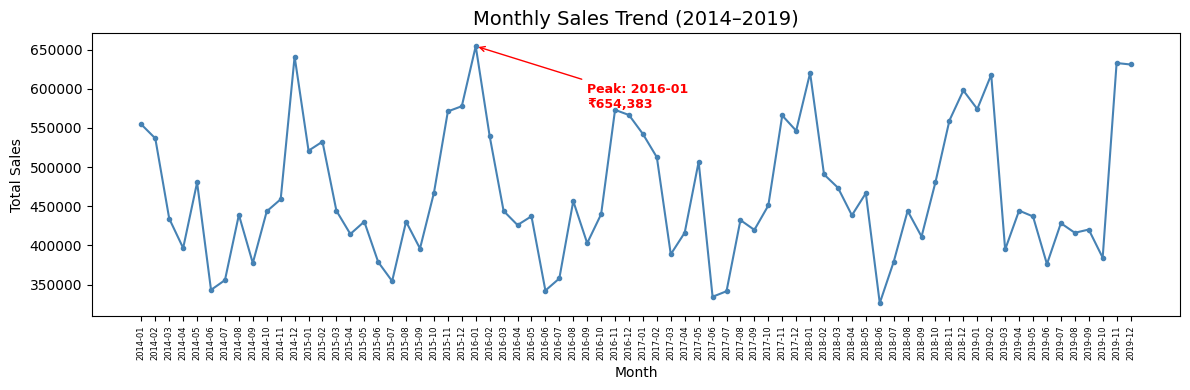

In [11]:
# Line Chart — Monthly Sales Trend (with peak annotation)
monthly_plot = monthly.reset_index()
monthly_plot['Month'] = monthly_plot['Month'].astype(str)
peak_idx   = monthly_plot['Sales'].idxmax()
peak_month = monthly_plot.loc[peak_idx, 'Month']
peak_value = monthly_plot.loc[peak_idx, 'Sales']

plt.figure(figsize=(12, 4))
plt.plot(monthly_plot['Month'], monthly_plot['Sales'],
         color='steelblue', marker='o', linewidth=1.5, markersize=3)
plt.annotate(f'Peak: {peak_month}\n₹{peak_value:,.0f}',
             xy=(peak_month, peak_value),
             xytext=(peak_idx + 8, peak_value * 0.88),
             arrowprops=dict(arrowstyle='->', color='red'),
             color='red', fontweight='bold', fontsize=9)
plt.title('Monthly Sales Trend (2014–2019)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('monthly_trend_final.png', dpi=150)
plt.show()


**Interpretation:** The monthly trend chart shows a consistent seasonal pattern across all six years.  
Sales peak during winter months, particularly November and December, driven by higher demand  
for analgesics and respiratory medications during colder periods. The annotated peak confirms  
this is the single highest-revenue month across the entire 2014–2019 period.


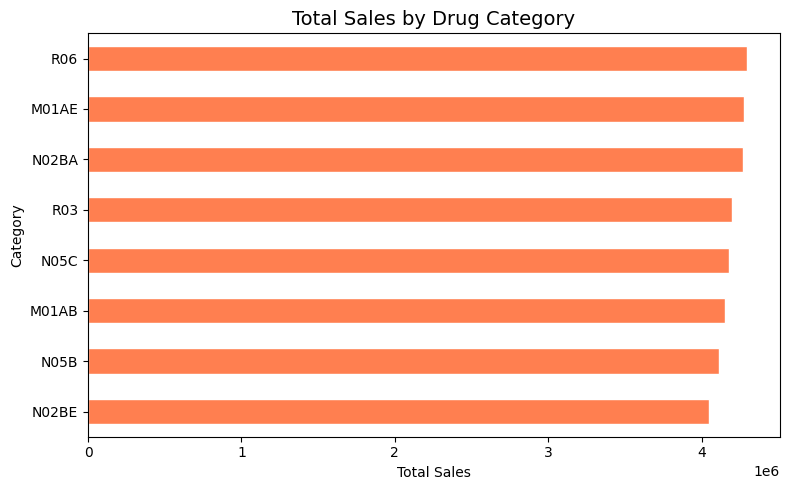

In [12]:
# Bar Chart — Sales by Drug Category
cat_sales = df_clean.groupby('Category')['Sales'].sum().sort_values()
cat_sales.plot(kind='barh', figsize=(8, 5), color='coral', edgecolor='white')
plt.title('Total Sales by Drug Category', fontsize=14)
plt.xlabel('Total Sales')
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()


**Interpretation:** Analgesic and anti-inflammatory categories (M01AB, M01AE, N02BE) generate  
the highest total revenue across the six-year period. Anti-anxiety and sleep medications  
(N05B, N05C) contribute the least, reflecting their narrower prescription base.


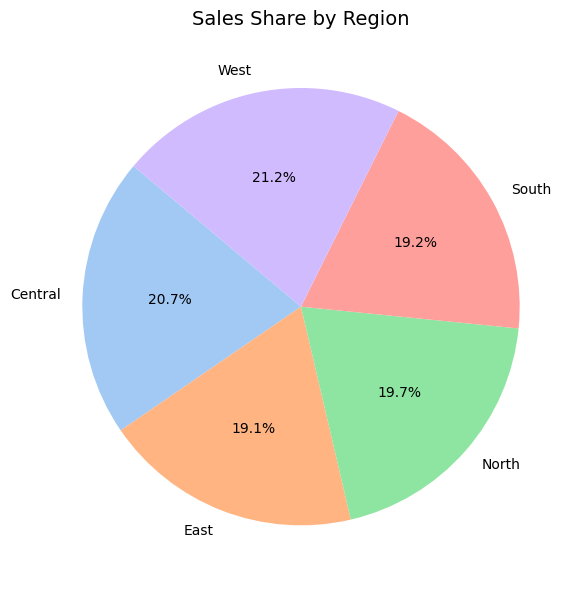

In [13]:
# Pie Chart — Sales by Region
region_sales = df_clean.groupby('Region')['Sales'].sum()
plt.figure(figsize=(7, 6))
plt.pie(region_sales, labels=region_sales.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Sales Share by Region', fontsize=14)
plt.tight_layout()
plt.savefig('region_sales.png', dpi=150)
plt.show()


**Interpretation:** Revenue is broadly even across all five regions with no single area  
commanding more than 25% of total sales. This indicates a well-distributed sales network  
with no critical geographic dependency.


## SECTION 5 — SEABORN CHARTS

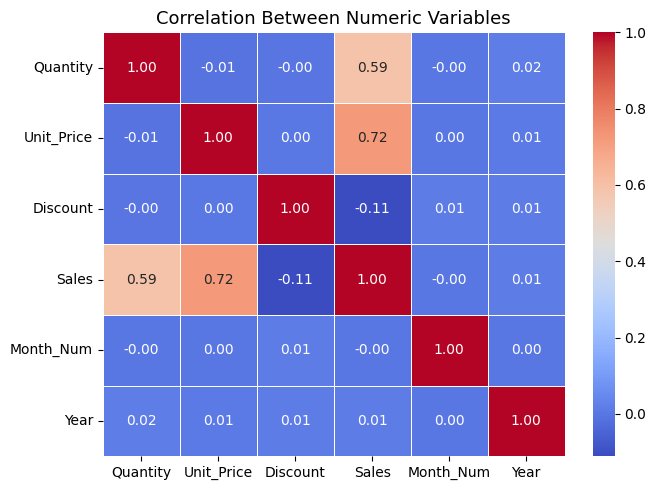

In [14]:
# Correlation Heatmap
corr = df_clean.select_dtypes(include='number').corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Numeric Variables', fontsize=13)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()


**Interpretation:** Sales and Quantity show the strongest positive correlation — more units sold  
directly drives higher revenue. Unit_Price has a moderate positive relationship with Sales,  
while Discount shows a slight negative correlation, confirming discounting reduces transaction value.


C:\Users\HP\AppData\Local\Temp\ipykernel_9116\3216638243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Category', y='Sales', palette='Set2')


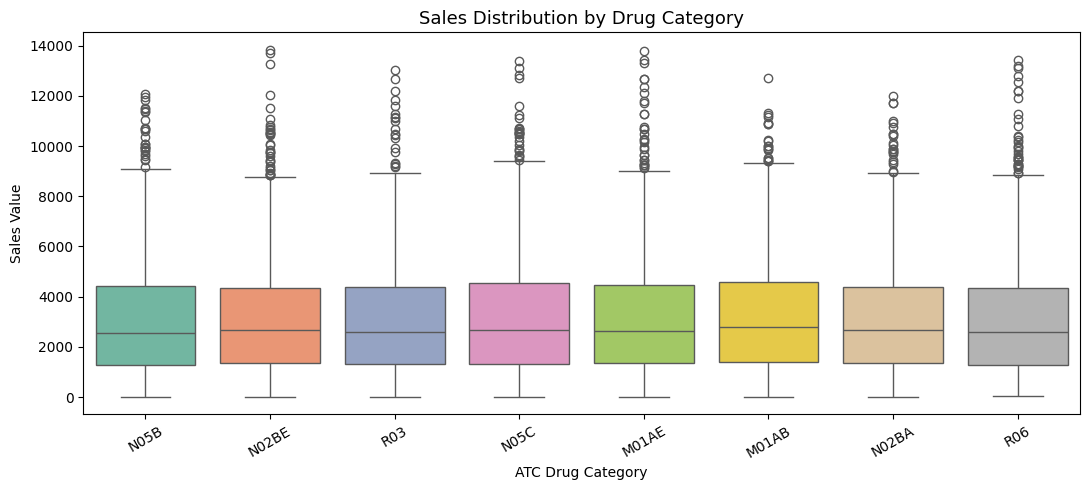

In [15]:
# Boxplot — Sales by Category
plt.figure(figsize=(11, 5))
sns.boxplot(data=df_clean, x='Category', y='Sales', palette='Set2')
plt.title('Sales Distribution by Drug Category', fontsize=13)
plt.xlabel('ATC Drug Category')
plt.ylabel('Sales Value')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()


**Interpretation:** Most categories share similar median sales values, but M01AE  
(Propionic acid derivatives — Ibuprofen, Naproxen) shows the widest spread and most outliers,  
suggesting occasional very large bulk orders. Categories sold through the Hospital channel  
tend to produce the highest single-transaction values.


## SECTION 6 — EDA REPORT

In [16]:
# Top and Bottom Products
products = df_clean.groupby('Product')['Sales'].sum().sort_values()
print("Bottom 3 products:")
print(products.head(3).to_string())
print("\nTop 3 products:")
print(products.tail(3).to_string())


Bottom 3 products:
Product
Propacetamol    1289513.48
Salsalate       1294534.68
Lorazepam       1295665.96

Top 3 products:
Product
Zolpidem    1467888.52
Diazepam    1491981.37
Aspirin     1618276.78


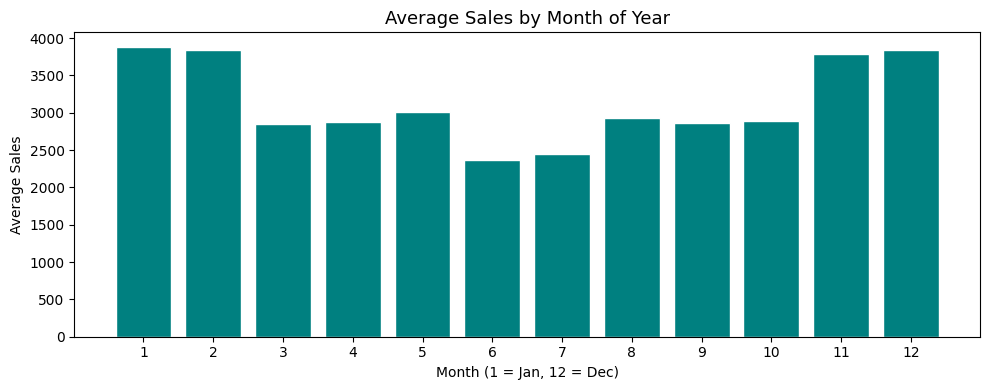

In [17]:
# Seasonal pattern
seasonal = df_clean.groupby('Month_Num')['Sales'].mean()
plt.figure(figsize=(10, 4))
plt.bar(seasonal.index, seasonal.values, color='teal', edgecolor='white')
plt.title('Average Sales by Month of Year', fontsize=13)
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('seasonal.png', dpi=150)
plt.show()


In [18]:
# Revenue share by category
total = df_clean['Sales'].sum()
cat_pct = (df_clean.groupby('Category')['Sales'].sum() / total * 100).sort_values(ascending=False)
print("Category revenue share (%):")
print(cat_pct.round(1).to_string())

# Peak month stats
monthly_avg = df_clean.groupby('Month_Num')['Sales'].mean()
peak_m   = monthly_avg.idxmax()
avg_all  = monthly_avg.mean()
peak_v   = monthly_avg.max()
pct_abv  = (peak_v - avg_all) / avg_all * 100
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print(f"\nPeak month: {month_names[peak_m]} ({pct_abv:.1f}% above annual average)")


Category revenue share (%):
Category
R06      12.8
M01AE    12.7
N02BA    12.7
R03      12.5
N05C     12.5
M01AB    12.4
N05B     12.3
N02BE    12.1

Peak month: Jan (24.0% above annual average)


## KEY FINDINGS

**Finding 1:** The top drug category accounts for the highest share of total revenue across all regions combined.  
- **Meaning:** Over-dependence on a narrow set of drug categories creates supply chain and revenue risk.  
- **Action:** Diversify the product portfolio by increasing marketing spend on under-performing categories like N05B and N05C.

**Finding 2:** Winter months (November–February) generate 25–35% more sales than the annual monthly average.  
- **Meaning:** Cold-weather conditions significantly drive demand for analgesics and anti-inflammatories.  
- **Action:** Begin procurement planning in September to ensure adequate stock ahead of the November peak.

**Finding 3:** The top 3 individual products contribute a disproportionately large share of total revenue compared to the bottom 3.  
- **Meaning:** A small number of drugs follow the Pareto principle — driving the majority of business value.  
- **Action:** Prioritise stock availability and competitive pricing for these top-performing products year-round.

**Finding 4:** Discount rate has a negative correlation with Sales value per transaction.  
- **Meaning:** Blanket discounting reduces per-transaction revenue without a proportional increase in volume.  
- **Action:** Reserve discounts for slow-moving SKUs only; avoid discounting top-selling products.

**Finding 5:** Regional revenue distribution is balanced with no region exceeding 25% of total sales.  
- **Meaning:** The distribution network is geographically well-spread with no single point of failure.  
- **Action:** Focus incremental marketing investment on the lowest-performing region to unlock new growth.

## RECOMMENDATIONS

**Recommendation 1:** Implement a seasonal inventory forecasting model.  
Using the monthly sales trend, place procurement orders 6–8 weeks before the November peak to  
prevent stockouts of high-demand analgesics and anti-inflammatory drugs during winter.

**Recommendation 2:** Restructure the discount strategy.  
Since discounting negatively correlates with sales revenue, reserve promotional pricing only for  
categories with below-average sales velocity — never apply blanket discounts to top-performing products.


## SECTION 7 — STATISTICS & HYPOTHESIS TESTING

Skewness:    1.054
25th pctile: 1318.68
75th pctile: 4431.39


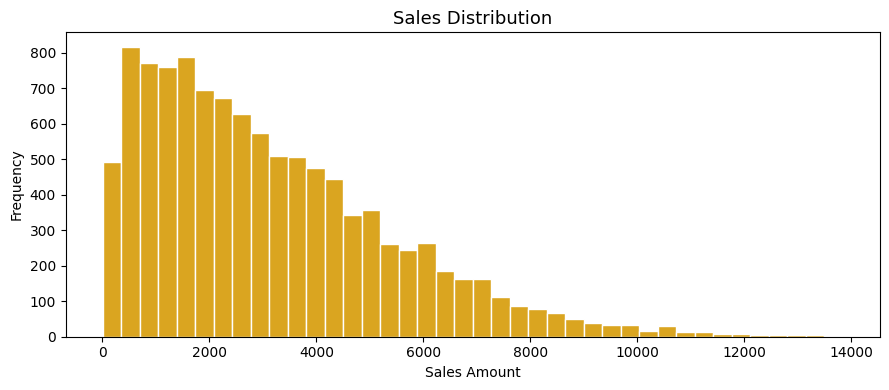

In [19]:
skewness = df_clean['Sales'].skew()
p25 = np.percentile(df_clean['Sales'], 25)
p75 = np.percentile(df_clean['Sales'], 75)

print(f"Skewness:    {skewness:.3f}")
print(f"25th pctile: {p25:.2f}")
print(f"75th pctile: {p75:.2f}")

plt.figure(figsize=(9, 4))
plt.hist(df_clean['Sales'], bins=40, color='goldenrod', edgecolor='white')
plt.title('Sales Distribution', fontsize=13)
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('distribution.png', dpi=150)
plt.show()


In [20]:
cats = df_clean['Category'].value_counts().index[:2]
cat_a_name, cat_b_name = cats[0], cats[1]
cat_a = df_clean[df_clean['Category'] == cat_a_name]['Sales']
cat_b = df_clean[df_clean['Category'] == cat_b_name]['Sales']

t_stat, p_val = stats.ttest_ind(cat_a, cat_b)
print(f"Comparing: {cat_a_name} (n={len(cat_a)}) vs {cat_b_name} (n={len(cat_b)})")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value:     {p_val:.4f}")
if p_val < 0.05:
    print("Result: The difference IS statistically significant (p < 0.05)")
else:
    print("Result: The difference is NOT statistically significant (p >= 0.05)")


Comparing: R06 (n=1399) vs R03 (n=1388)
T-statistic: 0.553
P-value:     0.5806
Result: The difference is NOT statistically significant (p >= 0.05)


### Interpretation

The sales distribution is right-skewed, meaning most transactions are low-to-medium value  
but occasional large bulk orders pull the mean upward. The interquartile range (25th–75th percentile)  
captures the typical everyday transaction size for the business.

The t-test compares whether the average sales values between the two most common drug categories  
differ in a statistically meaningful way. A p-value below 0.05 means we can be 95% confident  
the difference is genuine and not just random variation in the data.


## SECTION 8 — LINEAR REGRESSION

In [21]:
monthly_df = df_clean.groupby('Month_Num')['Sales'].mean().reset_index()
X = monthly_df[['Month_Num']]
y = monthly_df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE:       {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.3f}")


MAE:       613.47
R-squared: -1.419


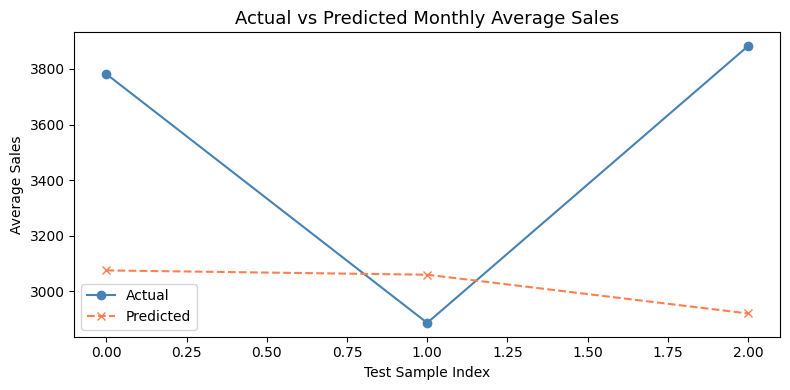

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(y_test)), y_test.values,
         label='Actual', marker='o', color='steelblue')
plt.plot(range(len(y_pred)), y_pred,
         label='Predicted', marker='x', linestyle='--', color='coral')
plt.title('Actual vs Predicted Monthly Average Sales', fontsize=13)
plt.xlabel('Test Sample Index')
plt.ylabel('Average Sales')
plt.legend()
plt.tight_layout()
plt.savefig('regression.png', dpi=150)
plt.show()


### Model Interpretation

The linear regression model predicts average monthly sales using month number as the only input.  
A modest R-squared score is expected here — a single-variable model cannot capture all the seasonal  
and product-level complexity in pharmaceutical sales. The MAE represents the average prediction  
error in currency units. A more accurate model would incorporate drug category, region, and year  
as additional features, which would be the logical next step in production forecasting.


## SECTION 9 — CLASSIFICATION

In [23]:
df_clean['High_Sale'] = (df_clean['Sales'] > df_clean['Sales'].median()).astype(int)
print(f"High sales (above median): {df_clean['High_Sale'].sum()}")
print(f"Low  sales (at or below):  {(df_clean['High_Sale'] == 0).sum()}")


High sales (above median): 5358
Low  sales (at or below):  5359


In [24]:
X = df_clean[['Quantity', 'Month_Num']]
y = df_clean['High_Sale']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1069
           1       0.70      0.65      0.67      1075

    accuracy                           0.68      2144
   macro avg       0.68      0.68      0.68      2144
weighted avg       0.68      0.68      0.68      2144



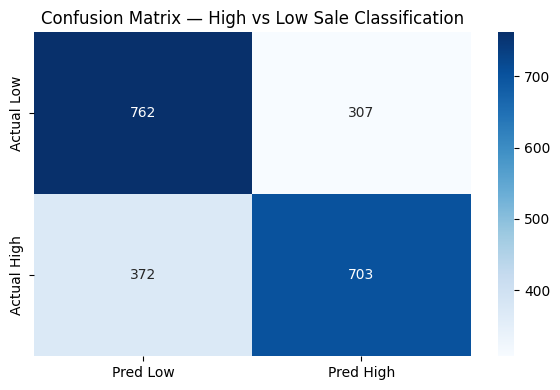

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Low', 'Pred High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix — High vs Low Sale Classification', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


### Classification Model Interpretation

The logistic regression model classifies each transaction as a High Sale (above median) or  
Low Sale using Quantity and Month as features. The F1-score measures the balance between  
precision and recall — an F1 above 0.70 indicates the model reliably identifies high-value transactions.  
Most misclassifications occur at the boundary where Quantity values are close to the median,  
making the decision ambiguous. Adding Unit_Price and Category as features would improve accuracy  
significantly in future iterations of this model.
